In [1]:
# Autoload modules
# %load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinSolver
import fcc
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit_aer.primitives import SamplerV2 as Sampler
import matplotlib.pyplot as plt
import ray
from tqdm import tqdm
import psutil
import json

In [3]:
num_workers = psutil.cpu_count(logical=False)
print(f"Number of workers: {num_workers}")
ray.init(
    num_cpus=num_workers,
    ignore_reinit_error=True,
    log_to_driver=False,
    runtime_env={
        "py_modules": [fcc],
    },
)

Number of workers: 12


2024-11-11 12:33:38,420	INFO worker.py:1807 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2024-11-11 12:33:38,429	INFO packaging.py:600 -- Creating a file package for local module '/Users/lir9/protein-folding-qc/notebooks/../fcc'.
2024-11-11 12:33:38,433	INFO packaging.py:392 -- Pushing file package 'gcs://_ray_pkg_161a99db8b601b5b.zip' (0.19MiB) to Ray cluster...
2024-11-11 12:33:38,435	INFO packaging.py:405 -- Successfully pushed file package 'gcs://_ray_pkg_161a99db8b601b5b.zip'.


Python version:,3.12.2
Ray version:,2.38.0
Dashboard:,http://127.0.0.1:8265


In [7]:
ray.shutdown()

### Basic routine

In [4]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    # print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun, penalty_olap)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(
        peptide, mj_interaction, penalty_terms
    )

    return protein_folding_problem

In [5]:
# main_seq = "LHPGAGK" # Zika
main_seq = "LFLF" # 6MVZ ("LFLF")
protein_folding_problem = build_pf(main_seq)

qubit_op = protein_folding_problem.qubit_op(r2_threshold=0.98)
print("Number of qubits: ", qubit_op.num_qubits)
print("Number of terms: ", len(qubit_op))
print(qubit_op)

Number of qubits:  9
Number of terms:  131
SparsePauliOp(['IIIIIIIII', 'IIIZZIIII', 'IIIZIZZII', 'IIIIZZZII', 'IIIIIIZZI', 'IIIZZIZZI', 'IIIZIZIZI', 'IIIIZZIZI', 'IIIIIZIIZ', 'IIIZZZIIZ', 'IIIZIIZIZ', 'IIIIZIZIZ', 'IIIIIZZZZ', 'IIIZZZZZZ', 'IIIZIIIZZ', 'IIIIZIIZZ', 'IIIIIZZII', 'IIIZZZZII', 'IIIIIIIZI', 'IIIIIZIII', 'IIIZIZIII', 'IIIIZZIII', 'IIIZZZIII', 'IIIIIIZII', 'IIIZIIZII', 'IIIIZIZII', 'IIIZZIZII', 'IIIIIZIZI', 'IIIZZZIZI', 'IIIZIIZZI', 'IIIZIIIII', 'IIIIZIIII', 'IIIIIIIZZ', 'IIIIIZIZZ', 'IIIZZZIZZ', 'IIIIIIZZZ', 'IIIZZIZZZ', 'IIIZIZZZZ', 'IIIIZZZZZ', 'IIIIZZIIZ', 'IIIIZIZZI', 'IIIZIIIZI', 'IIIIZIIZI', 'IIIZZIIZI', 'IIIIIZZZI', 'IIIZIZZZI', 'IIIIZZZZI', 'IIIZZZZZI', 'IIIIIIIIZ', 'IIIZIIIIZ', 'IIIIZIIIZ', 'IIIIIIZIZ', 'IIIZZIZIZ', 'IIIZIZZIZ', 'IIIIZZZIZ', 'IIIIZZIZZ', 'IIIIZIZZZ', 'IIIZIZIZZ', 'IIIZZIIZZ', 'IIIZIIZZZ', 'IIIZIZIIZ', 'IIIZZIIIZ', 'IIIZZZZIZ', 'IIIIIZZIZ', 'IIZIIIIII', 'IIZIIIIZI', 'IIZIIIIZZ', 'IZIIIIIII', 'IZIIIIIZI', 'IZIIIZIII', 'IZIZIZIII', 'IZIIZZIII', 'IZIZZ

Below we incorporate the sampling VQE approach, where we store all the configurations sampled during the VQE optimization. In the end, we choose the top N configurations as the final result and save them in a file.

In [23]:
shots = 10_000
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 100
num_batches = num_workers

protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=True)

 >> Sampler job took 0.02 seconds
 >> Processing 329 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 49 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 56 unique bitstrings took 0.01 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 42 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 13 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 7 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 6 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 3 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 0 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 1 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >> Processing 3 unique bitstrings took 0.00 seconds
 >> Sampler job took 0.02 seconds
 >>

In [24]:
opt_results

{'final_cost': -18.616013986013932,
 'opt_params': array([10.505797  ,  7.59050722, 11.49763178, 11.20689747,  1.46434821,
         7.67738471,  4.03988899, 11.7494299 ,  5.69597148, 10.4680701 ,
         3.87228217, 10.47168476, 11.33009614,  3.46244989,  3.87417235,
         3.73708293,  2.52048917,  5.86756134]),
 'cost_trajectory': [-11.944376223776192,
  -11.456946153846157,
  -14.466958041957998,
  -12.857661538461496,
  -12.785665734265693,
  -14.280163636363602,
  -16.938131468531424,
  -16.0257636363636,
  -15.057987412587364,
  -11.64453426573422,
  -18.616013986013932,
  -18.616013986013932,
  -18.13004755244752,
  -18.58593846153847,
  -13.921474125874145,
  -18.616013986013932,
  -18.616013986013932,
  -18.616013986013932,
  -11.715881118881073,
  -18.616013986013932,
  -16.72152167832164,
  -18.616013986013932,
  -18.616013986013932,
  -18.24862797202793,
  -18.616013986013932,
  -18.0314545454545,
  -18.279069930069884,
  -18.616013986013932,
  -18.616013986013932,
  -18

In [25]:
from fcc.fcc_protein_shape import ProteinShapeDecoder

best_solution = opt_results["top_solutions"][0][0]
print(best_solution)
shape_decoder = ProteinShapeDecoder(protein_folding_problem.peptide, solution_bitstring=best_solution)
print(shape_decoder.turn_sequence)

101100110
[0, 9, 4]


### Extract classical results

In [6]:
cs_dir = "../classical_search/cs_res/"
file_name = f"{main_seq}_topobj.txt"

In [7]:
def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list[str]:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append(relabel_turns(turns))
    return top_cls_turns

In [8]:
load_top_cls_solns(file_name)

['390',
 '190',
 'b90',
 '090',
 '490',
 '520',
 '720',
 '180',
 'a90',
 '590',
 '990',
 '290',
 '690',
 '120',
 '500',
 '700',
 '280',
 '900',
 'b00',
 '680',
 '820',
 'a20',
 '580',
 '300',
 'b80',
 '080',
 '920',
 'b20',
 '480',
 '020',
 '000',
 '220',
 '880',
 '200',
 '420',
 'a80',
 '400',
 '620',
 '600',
 '380',
 '800',
 'a00',
 '780',
 '000',
 '000',
 '000',
 '000',
 '000',
 '000',
 '000']

In [9]:
def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

In [10]:
print(convert_bitstring_to_turns("111111110", main_seq))
print(convert_bitstring_to_turns("100011111", main_seq))

390
x20


### How does different R^2 threshold affect the quality of solutions?

In [17]:
shots = 10_000
sampler = Sampler(default_shots=shots)

optimizer = "COBYLA"
maxiter = 200
num_batches = num_workers

In [12]:
main_seq = "LFLF" # 6MVZ ("LFLF")
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_turns_list = []

r2_thresholds = [0.95, 0.96, 0.97, 0.98, 0.99, 0.992, 0.994, 0.996, 0.998]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_per_r2 = [sol[0] for sol in opt_results["top_solutions"][0:20]]
    top_turns_per_r2 = [convert_bitstring_to_turns(soln, main_seq) for soln in top_bitstrings_per_r2]
    top_turns_list.append(top_turns_per_r2)

100%|██████████| 9/9 [00:21<00:00,  2.35s/it]


In [13]:
# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{main_seq}_topobj.txt")[:20]

# Compare how many of the top 20 solutions from the quantum search are in the top 20 solutions from the classical search
overlapping_solutions_ratio = []
for top_turns_per_r2 in top_turns_list:
    overlapping_solutions = [turns for turns in top_turns_per_r2 if turns in top_cls_turns]
    overlapping_solutions_ratio.append(len(overlapping_solutions) / 20)

print(overlapping_solutions_ratio)

[0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95]


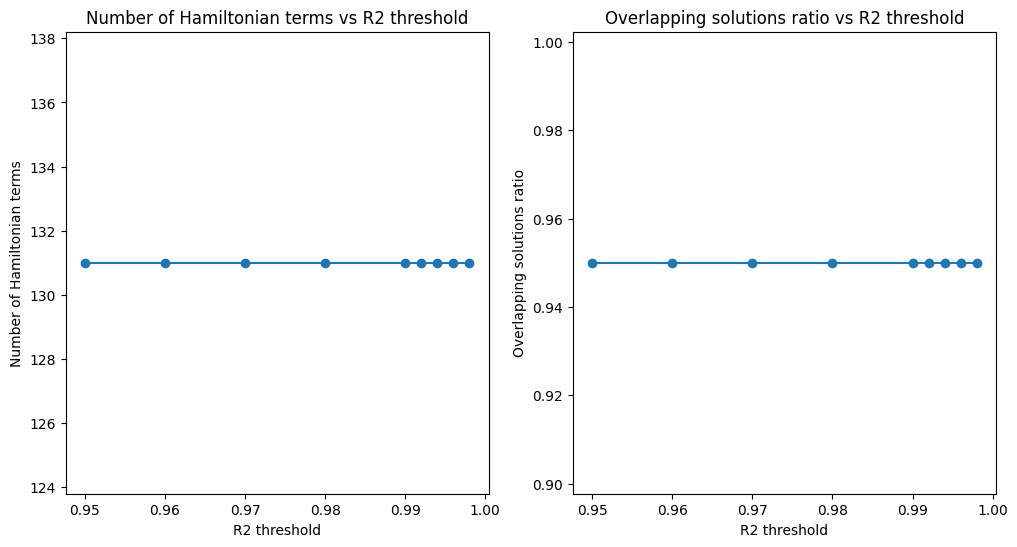

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(r2_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xlabel("R2 threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs R2 threshold")

axs[1].plot(r2_thresholds[0:len(r2_thresholds)], overlapping_solutions_ratio, marker='o')
axs[1].set_xlabel("R2 threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs R2 threshold")

plt.show()


In [18]:
main_seq = "GNLVS" # 4QXX
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_turns_list = []

r2_thresholds = r2_thresholds = [0.9, 0.95, 0.98, 0.99, 0.995, 0.998, 0.999]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_per_r2 = [sol[0] for sol in opt_results["top_solutions"][0:20]]
    top_turns_per_r2 = [convert_bitstring_to_turns(soln, main_seq) for soln in top_bitstrings_per_r2]
    top_turns_list.append(top_turns_per_r2)

# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{main_seq}_topobj.txt")[:20]

# Compare how many of the top 20 solutions from the quantum search are in the top 20 solutions from the classical search
overlapping_solutions_ratio = []
for top_turns_per_r2 in top_turns_list:
    overlapping_solutions = [turns for turns in top_turns_per_r2 if turns in top_cls_turns]
    overlapping_solutions_ratio.append(len(overlapping_solutions) / 20)

print(overlapping_solutions_ratio)
    

100%|██████████| 7/7 [00:42<00:00,  6.06s/it]

[0.0, 0.3, 0.65, 1.0, 0.95, 0.95, 0.95]


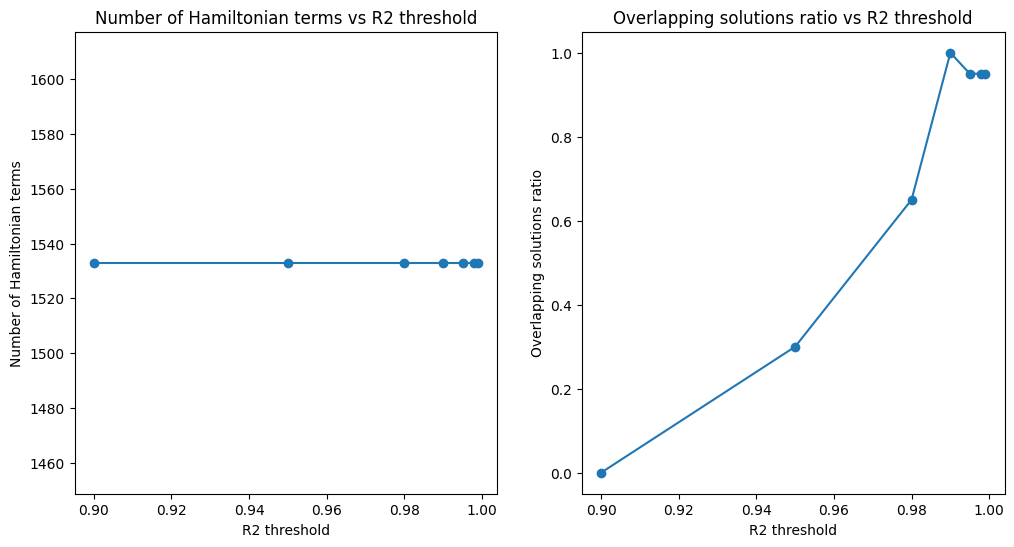

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(r2_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xlabel("R2 threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs R2 threshold")

axs[1].plot(r2_thresholds[0:len(r2_thresholds)], overlapping_solutions_ratio, marker='o')
axs[1].set_xlabel("R2 threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs R2 threshold")

fig.suptitle("GNLVS (5 AAs)")

plt.show()


In [21]:
main_seq = "SNQNNF" # 2OL9
protein_folding_problem = build_pf(main_seq)
num_hamiltonian_terms = []
top_turns_list = []

r2_thresholds = r2_thresholds = [0.9, 0.95, 0.98, 0.99, 0.995, 0.998, 0.999]
for r2_threshold in tqdm(r2_thresholds):
    qubit_op = protein_folding_problem.qubit_op(r2_threshold=r2_threshold)
    num_hamiltonian_terms.append(len(qubit_op))

    ansatz = RealAmplitudes(qubit_op.num_qubits, reps=1).decompose()
    protein_solver = ProteinSolver(ansatz=ansatz, hamiltonian=qubit_op, sampler=sampler)
    opt_results = protein_solver.train(optimizer=optimizer, maxiter=maxiter, num_batches=num_batches, verbose=False)
    top_bitstrings_per_r2 = [sol[0] for sol in opt_results["top_solutions"][0:20]]
    top_turns_per_r2 = [convert_bitstring_to_turns(soln, main_seq) for soln in top_bitstrings_per_r2]
    top_turns_list.append(top_turns_per_r2)

# Get the top 20 solutions from classical search
top_cls_turns = load_top_cls_solns(f"{main_seq}_topobj.txt")[:20]

# Compare how many of the top 20 solutions from the quantum search are in the top 20 solutions from the classical search
overlapping_solutions_ratio = []
for top_turns_per_r2 in top_turns_list:
    overlapping_solutions = [turns for turns in top_turns_per_r2 if turns in top_cls_turns]
    overlapping_solutions_ratio.append(len(overlapping_solutions) / 20)

print(overlapping_solutions_ratio)
        

100%|██████████| 7/7 [17:29<00:00, 149.93s/it]

[0.0, 0.0, 0.75, 0.8, 0.65, 0.85, 0.95]


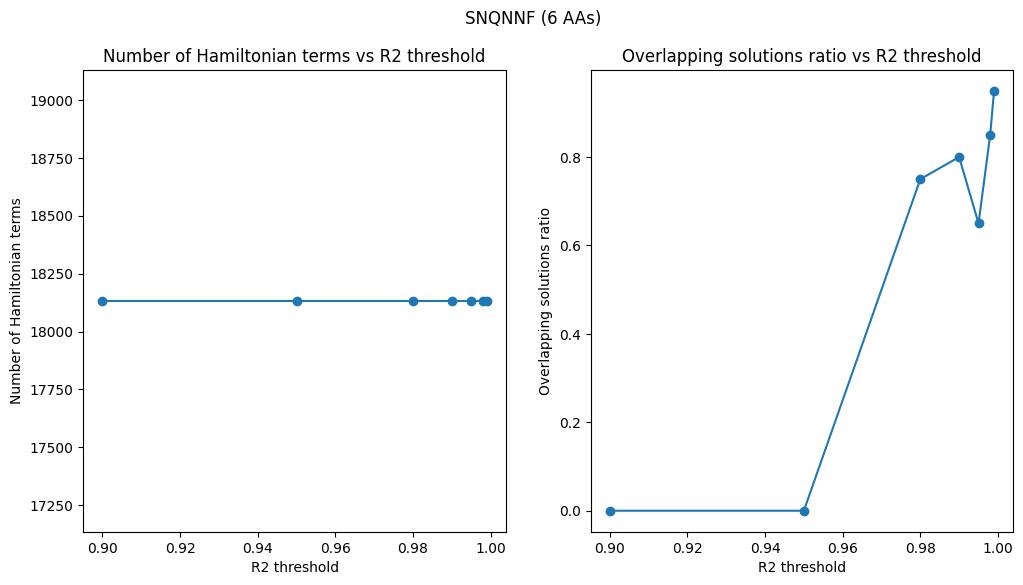

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(r2_thresholds, num_hamiltonian_terms, marker='o')
axs[0].set_xlabel("R2 threshold")
axs[0].set_ylabel("Number of Hamiltonian terms")
axs[0].set_title("Number of Hamiltonian terms vs R2 threshold")

axs[1].plot(r2_thresholds[0:len(r2_thresholds)], overlapping_solutions_ratio, marker='o')
axs[1].set_xlabel("R2 threshold")
axs[1].set_ylabel("Overlapping solutions ratio")
axs[1].set_title("Overlapping solutions ratio vs R2 threshold")

fig.suptitle("SNQNNF (6 AAs)")

plt.show()
